# When does white voluntarily play Rb5?

Across nearly a million master-level chess games, how often does white move a rook to b5 *without capturing anything*, how soon does it happen, and how much material is usually still on the board when it does?

Captures on b5 are filtered out throughout — we're studying the rook lift / sideways shift as a positional choice, not Rxb5 trades.

## The dataset

**Lumbra's Gigabase OTB Elite** (June 2026 release):

- ~909,000 over-the-board games (no online play, no correspondence)
- Both players Elo ≥2400 — roughly FIDE Master and above
- Aggregated across TWIC weekly tournament PGNs, the (now-defunct) Caissabase historical corpus, national federation archives (BCF, Italian, Danish, Greek, Scottish, …), and live-broadcast capture from Lichess
- Date range 1848 to 2026; sparse pre-1900 (ratings retroactively assigned), dense post-2000

Each parquet shard preserves the full original PGN per game, so we can replay every position with `python-chess` and ask move-by-move questions like the ones below.

**Sample vs full corpus.** This notebook ships with a 100-game sample under `data/sample/games/`. To run against the full ~900k-game corpus, run `make data` once (~5 min for the download + index) and flip `USE_FULL_CORPUS = True` below. Position-level analysis of the full corpus takes ~90 seconds on a 14-core mac.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

from chess_corpus.analysis import map_shards, white_quiet_rook_to_b5

USE_FULL_CORPUS = False

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SHARD_DIR = ROOT / ("data/processed/games" if USE_FULL_CORPUS else "data/sample/games")
print(f"Reading shards from {SHARD_DIR}")

Reading shards from /Users/paul/pwsiegel/chess-move-stats/data/sample/games


/Users/paul/pwsiegel/chess-move-stats/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Replay every game and extract Rb5 stats

`white_quiet_rook_to_b5` walks each game's mainline once and records, per game, the first move number on which white moved a rook to b5 *without capturing anything*, plus the material on the board at that moment. Material is the standard P=1 N=B=3 R=5 Q=9 sum across both sides, kings excluded. Since material decreases monotonically through a game, the first Rb5 also corresponds to the highest material at any Rb5.

`map_shards` parallelizes across parquet shards (13 shards on the full corpus → one wave on 13 workers).

In [2]:
rb5 = pd.DataFrame(map_shards(white_quiet_rook_to_b5, shard_dir=SHARD_DIR))
print(f"Replayed {len(rb5):,} games.")
rb5.head()

shards:   0%|          | 0/1 [00:00<?, ?it/s]

shards: 100%|██████████| 1/1 [00:00<00:00,  3.08it/s]

shards: 100%|██████████| 1/1 [00:00<00:00,  3.07it/s]

Replayed 100 games.


,first_rb5_fullmove,first_rb5_material,n_white_moves
0,NaN,NaN,41
1,NaN,NaN,35
2,NaN,NaN,27
3,NaN,NaN,23
4,NaN,NaN,27


## How often does white voluntarily play Rb5?

First the unconditional rate: out of every master game in the corpus, what fraction sees white move a rook to b5 voluntarily (i.e. b5 was empty when the rook arrived)?

In [3]:
n_total = len(rb5)
n_with_rb5 = int(rb5["first_rb5_fullmove"].notna().sum())
pct = 100 * n_with_rb5 / n_total
print(f"Among all {n_total:,} games, {n_with_rb5:,} of them had white voluntarily playing Rb5 — that comes out to {pct:.2f}%.")

Among all 100 games, 4 of them had white voluntarily playing Rb5 — that comes out to 4.00%.


## When in the game does Rb5 happen? (CDF over move number)

Restrict to games where white voluntarily plays Rb5, then ask: how soon does it happen? We record the **first** move number on which white moves a rook to b5, and build a cumulative distribution: P(first Rb5 ≤ move N | white plays Rb5).

**How to read the chart:** *"Among the games where white plays Rb5, the probability that it happens by move N is Y."* For example, the cell below pulls out the value at N=30 — that's how to phrase any point on the curve.

In [4]:
played = rb5[rb5["first_rb5_fullmove"].notna()].copy()
played["first_rb5_fullmove"] = played["first_rb5_fullmove"].astype(int)
played["first_rb5_material"] = played["first_rb5_material"].astype(int)

max_n = 80
ns = np.arange(1, max_n + 1)
cdf_move = pd.DataFrame(
    {"N": ns, "prob": [(played["first_rb5_fullmove"] <= n).mean() for n in ns]}
)

example_n = 30
ex_p = cdf_move.loc[cdf_move["N"] == example_n, "prob"].iloc[0]
print(
    f"Example: among the {len(played):,} games where white plays Rb5, "
    f"the probability that it happens by move {example_n} is {ex_p:.1%}."
)

Example: among the 4 games where white plays Rb5, the probability that it happens by move 30 is 75.0%.


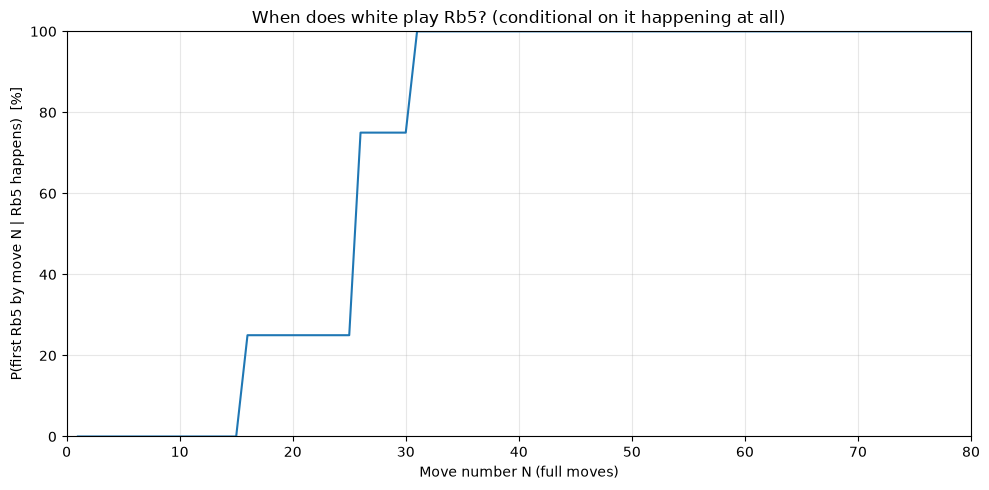

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cdf_move["N"], cdf_move["prob"] * 100)
ax.set_xlabel("Move number N (full moves)")
ax.set_ylabel("P(first Rb5 by move N | Rb5 happens)  [%]")
ax.set_title("When does white play Rb5? (conditional on it happening at all)")
ax.grid(alpha=0.3)
ax.set_xlim(0, max_n)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## How much material is on the board when Rb5 happens? (survival CDF over material)

Still restricted to games where white plays Rb5. The starting position has 78 points of material total (39 per side: 8 pawns + 2 knights + 2 bishops + 2 rooks + 1 queen). We record the material on the board immediately after the **first** Rb5 in each game — material is monotonically non-increasing during a game, so the first Rb5 is the highest-material Rb5 in the game, and "Rb5 happened with ≥ X material" is equivalent to "the first Rb5 happened with ≥ X material".

**How to read the chart:** *"Among the games where white plays Rb5, the probability that the move happens with ≥ X total points of material on the board is Y."* See the example sentence in the next cell.

In [6]:
first_mat = played["first_rb5_material"]
xs = np.arange(0, 79)
cdf_mat = pd.DataFrame({"X": xs, "prob": [(first_mat >= x).mean() for x in xs]})

example_x = 40
ex_p = cdf_mat.loc[cdf_mat["X"] == example_x, "prob"].iloc[0]
print(
    f"Example: among the {len(played):,} games where white plays Rb5, "
    f"the probability that the move happens with ≥{example_x} points of material on the board is {ex_p:.1%}."
)

Example: among the 4 games where white plays Rb5, the probability that the move happens with ≥40 points of material on the board is 100.0%.


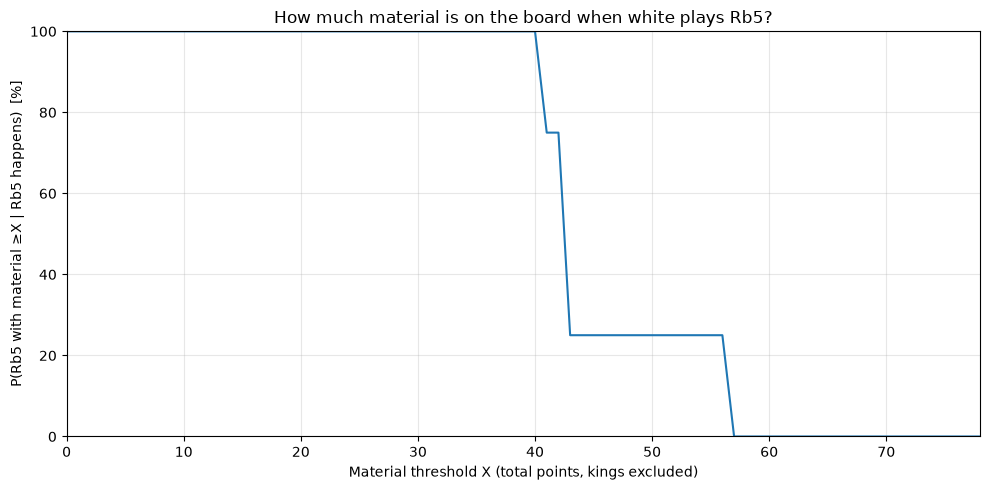

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cdf_mat["X"], cdf_mat["prob"] * 100)
ax.set_xlabel("Material threshold X (total points, kings excluded)")
ax.set_ylabel("P(Rb5 with material ≥X | Rb5 happens)  [%]")
ax.set_title("How much material is on the board when white plays Rb5?")
ax.set_xlim(0, 78)
ax.grid(alpha=0.3)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Top 10 highest-rated players to voluntarily play Rb5

Group all games with a voluntary white Rb5 by the white player. For each player, take their **peak rating** across those games (the highest white Elo they had in any game where they played Rb5) and count how many such games they have. Sort by peak rating, take the top 10.

In [8]:
# Align rb5 rows with the parquet's header columns. map_shards iterates
# sorted(glob) and preserves intra-shard order; pa.concat_tables over the
# same sorted shard list preserves the same order, so positional indices match.
shards = sorted(SHARD_DIR.glob("*.parquet"))
header_table = pa.concat_tables(
    [
        pq.read_table(
            s,
            columns=["white", "white_elo", "black", "black_elo", "event", "date", "result"],
        )
        for s in shards
    ]
)
headers_df = header_table.to_pandas().reset_index(drop=True)
combined = pd.concat([rb5.reset_index(drop=True), headers_df], axis=1)

# Games where white voluntarily played Rb5, with a known white Elo.
played_rb5 = combined[
    combined["first_rb5_fullmove"].notna() & combined["white_elo"].notna()
]

player_stats = (
    played_rb5.groupby("white")
    .agg(peak_elo=("white_elo", "max"), n_rb5_games=("first_rb5_fullmove", "size"))
    .reset_index()
    .sort_values("peak_elo", ascending=False)
)
top10_players = player_stats.head(10)
top10_players

,white,peak_elo,n_rb5_games
2,"Grischuk, Alexander",2781,1
0,"Beikert, Guenther, Dr.",2438,1
1,"Bellon Lopez, Juan Manuel",2415,2


### Sample games for the top 5

For each of the top 5 players, pick the single game where their white Elo was highest (i.e. their best-rated Rb5 game in the corpus) and print the PGN — paste any block into a Lichess analysis board (https://lichess.org/paste).

In [9]:
pgn_table = pa.concat_tables([pq.read_table(s, columns=["pgn"]) for s in shards])
pgns = pgn_table.to_pandas().reset_index(drop=True)["pgn"]

for i, player_name in enumerate(top10_players["white"].head(5), start=1):
    # That player's highest-rated Rb5 game.
    sample = played_rb5[played_rb5["white"] == player_name].nlargest(1, "white_elo").iloc[0]
    idx = sample.name

    print(
        f"# {i}. {sample['white']} ({int(sample['white_elo'])}) vs "
        f"{sample['black']} ({int(sample['black_elo']) if pd.notna(sample['black_elo']) else '?'})  "
        f"— {sample['event']}, {sample['date']}, result {sample['result']}"
    )
    print(
        f"# first Rb5: move {int(sample['first_rb5_fullmove'])} with "
        f"{int(sample['first_rb5_material'])} points of material on the board\n"
    )
    print(pgns.iloc[idx])
    print("\n" + "=" * 80 + "\n")

# 1. Grischuk, Alexander (2781) vs Vachier-Lagrave, Maxime (2723)  — 3. Norway Blitz 2015, 2015.06.15, result 1/2-1/2
# first Rb5: move 31 with 56 points of material on the board

[Event "3. Norway Blitz 2015"]
[Site "Stavanger NOR"]
[Date "2015.06.15"]
[Round "6.3"]
[White "Grischuk, Alexander"]
[Black "Vachier-Lagrave, Maxime"]
[Result "1/2-1/2"]
[PlyCount "101"]
[WhiteElo "2781"]
[WhiteFideId "4126025"]
[WhiteTitle "GM"]
[BlackElo "2723"]
[BlackFideId "623539"]
[BlackTitle "GM"]
[ECO "B23m"]
[Source "PGNMentor"]
[SourceQuality "1"]
[ImportDate "2026-01-06"]

1. Nc3 c5 2. e4 Nc6 3. Bb5 Nd4 4. Nf3 a6 5. Bd3 Nc6 6. e5 e6 7. O-O d5 8. exd6 Bxd6 9. Ne4 Be7 10. b3 f5 11. Ng3 Bf6 12. Rb1 g6 13. Re1 Nge7 14. Bb2 Bxb2 15. Rxb2 O-O 16. a4 Nd5 17. Bc4 Qf6 18. Rb1 Bd7 19. c3 Rad8 20. b4 cxb4 21. Bxd5 exd5 22. cxb4 f4 23. Nf1 Bg4 24. h3 Bxf3 25. Qxf3 Nd4 26. Qd3 f3 27. g3 Ne2+ 28. Kh2 d4 29. b5 a5 30. b6 Kh8 31. Rb5 Rc8 32. Rxa5 Qxb6 33. Rb5 Qa6 34. Qb3 Rc7 35. Rb1 Rff7 36. a5 Qf6 37. Qd5 Rcd7 3